In [40]:
import time

import matplotlib.pyplot as plt
import numpy as np
import skimage.io

(128, 32, 4)
uint8


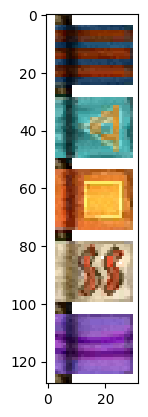

In [41]:
im = skimage.io.imread("test-image.png")
print(im.shape)
print(im.dtype)
plt.imshow(im, interpolation="nearest")

im_h, im_w, im_channels = im.shape

if im_channels != 4:
    raise Exception("image is not RGB + alpha")

if im.dtype != np.uint8:
    # actually we are only checking for 0 alpha so float would work too
    raise NotImplementedError(im.dtype)

In [42]:
def get_closest_pixel_with_non_zero_alpha_naive(im, tx, ty):
    im_h, im_w, im_channels = im.shape
    assert im_channels == 4
    closest_dist = None
    closest_x = None
    closest_y = None
    for x in range(im_w):
        for y in range(im_h):
            if im[y, x, 3] != 0:
                dist = np.sqrt(np.square(tx - x) + np.square(ty - y))
                if closest_dist is None or dist < closest_dist:
                    closest_dist = dist
                    closest_x = x
                    closest_y = y
    assert closest_dist is not None, "did not find any pixel with non zero alpha"
    return closest_x, closest_y


def alpha_bleeder_naive(im):
    im_h, im_w, im_channels = im.shape
    assert im_channels == 4

    painted_im = im.copy()

    for x in range(im_w):
        for y in range(im_h):
            if im[y, x, 3] == 0:
                cx, cy = get_closest_pixel_with_non_zero_alpha_naive(im, x, y)
                painted_im[y, x, :3] = im[cy, cx, :3]

    return painted_im

painted_im = alpha_bleeder_naive(im)

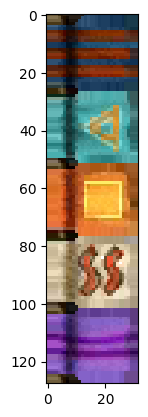

In [43]:
plt.imshow(painted_im[:,:,:3], interpolation="nearest")

[(3, 3), (4, 3), (5, 3), (6, 3), (7, 3), (7, 4), (7, 5), (7, 6), (7, 7), (3, 7), (4, 7), (5, 7), (6, 7), (3, 4), (3, 5), (3, 6)]


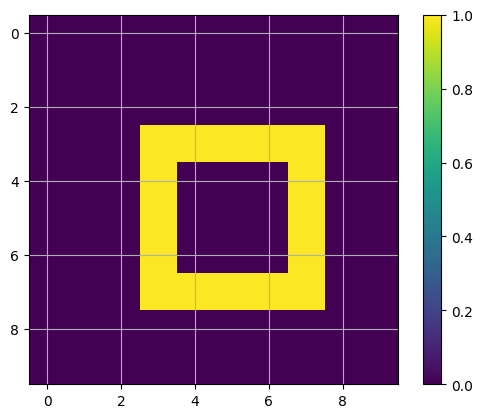

In [44]:
def enumerate_around(tx, ty, radius, w, h):
    # +--A--+
    # |     |
    # D  t  B
    # |     |
    # +--C--+

    # A
    if ty - radius >= 0:
        yield from (
            (x, ty - radius) for x in range(max(0, tx - radius), min(tx + radius, w))
        )
    # B
    if tx + radius < w:
        yield from (
            (tx + radius, y)
            for y in range(max(0, ty - radius), min(ty + radius + 1, h))
        )
    # C
    if ty + radius < h:
        yield from (
            (x, ty + radius) for x in range(max(0, tx - radius), min(tx + radius, w))
        )
    # D
    if tx - radius >= 0:
        yield from (
            (tx - radius, y)
            for y in range(max(0, ty - radius + 1), min(ty + radius, h))
        )


positions = list(enumerate_around(5, 5, 2, 10, 10))
print(positions)
dbg = np.zeros((10, 10))
for x, y in positions:
    dbg[y, x] += 1
plt.imshow(dbg)
plt.grid()
plt.colorbar()


def get_closest_pixel_with_non_zero_alpha_naive_opt_search(im, tx, ty):
    im_h, im_w, im_channels = im.shape
    assert im_channels == 4
    closest_dist = None
    closest_x = None
    closest_y = None
    r = 0
    while True:
        any_enumerated = False
        for x, y in enumerate_around(tx, ty, r, im_w, im_h):
            any_enumerated = True
            if im[y, x, 3] != 0:
                dist = np.sqrt(np.square(tx - x) + np.square(ty - y))
                if closest_dist is None or dist < closest_dist:
                    closest_dist = dist
                    closest_x = x
                    closest_y = y
        assert any_enumerated, "did not find any pixel with non zero alpha"
        if closest_dist is not None:
            return closest_x, closest_y
        r += 1


def alpha_bleeder_naive_opt_search(im):
    im_h, im_w, im_channels = im.shape
    assert im_channels == 4

    painted2_im = im.copy()

    for x in range(im_w):
        for y in range(im_h):
            if im[y, x, 3] == 0:
                cx, cy = get_closest_pixel_with_non_zero_alpha_naive_opt_search(
                    im, x, y
                )
                painted2_im[y, x, :3] = im[cy, cx, :3]

    return painted2_im


painted2_im = alpha_bleeder_naive_opt_search(im)

False


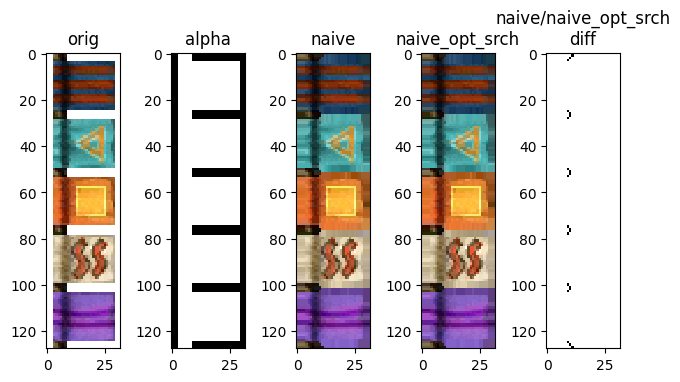

In [45]:
print(np.all(painted_im == painted2_im))
fig, axs = plt.subplots(1, 5)
axs[0].imshow(im, interpolation="nearest")
axs[0].set_title("orig")
axs[1].imshow(im[:, :, 3], cmap="gray", interpolation="nearest")
axs[1].set_title("alpha")
axs[2].imshow(painted_im[:, :, :3], interpolation="nearest")
axs[2].set_title("naive")
axs[3].imshow(painted2_im[:, :, :3], interpolation="nearest")
axs[3].set_title("naive_opt_srch")
axs[4].imshow(
    np.all(painted2_im == painted_im, axis=2) + 0, cmap="gray", interpolation="nearest"
)
axs[4].set_title("naive/naive_opt_srch\ndiff")
fig.tight_layout()

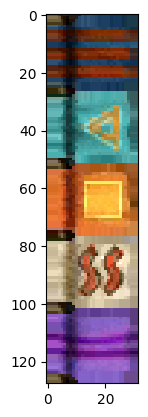

In [46]:
def neighbouring_coords(x, y, w, h):
    if y - 1 >= 0:
        yield x, y - 1
    if x + 1 < w:
        yield x + 1, y
    if y + 1 < h:
        yield x, y + 1
    if x - 1 >= 0:
        yield x - 1, y


inf = float("inf")


def distance(x1, y1, x2, y2):
    return np.square(x1 - x2) + np.square(y1 - y2)


def alpha_bleeder_extend_neighbours(im):
    im_h, im_w, im_channels = im.shape
    assert im_channels == 4

    painted_im = im.copy()

    closest = {}

    while True:
        expand_to = []
        for y in range(im_h):
            for x in range(im_w):
                if painted_im[y, x, 3] == 0:
                    for nx, ny in neighbouring_coords(x, y, im_w, im_h):
                        if painted_im[ny, nx, 3] != 0:
                            expand_to.append((x, y))
                            break
        if not expand_to:
            break
        for x, y in expand_to:
            cdist = None
            cx = None
            cy = None
            for nx, ny in neighbouring_coords(x, y, im_w, im_h):
                if painted_im[ny, nx, 3] != 0:
                    ncx, ncy = closest.get((nx, ny), (nx, ny))
                    dist = distance(x, y, ncx, ncy)
                    if cdist is None or dist < cdist:
                        cx = ncx
                        cy = ncy
                        cdist = dist
            assert cdist is not None
            painted_im[y, x, :] = painted_im[cy, cx, :]
            closest[(x, y)] = (cx, cy)
    painted_im[:, :, 3] = im[:, :, 3]

    return painted_im


painted3_im = alpha_bleeder_extend_neighbours(im)
plt.imshow(painted3_im[:, :, :3], interpolation="nearest")

True


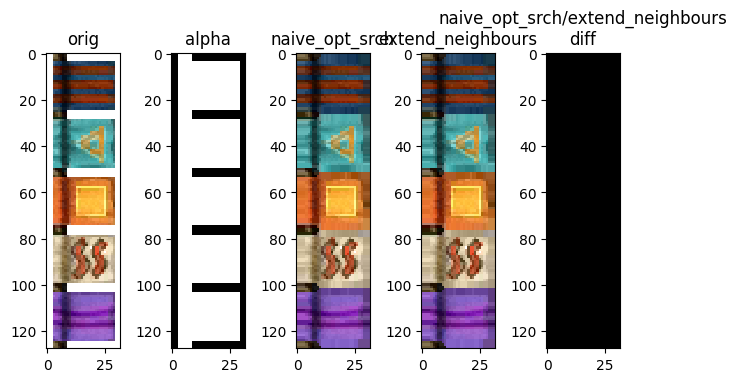

In [47]:
print(np.all(painted2_im == painted3_im))
fig, axs = plt.subplots(1, 5)
axs[0].imshow(im, interpolation="nearest")
axs[0].set_title("orig")
axs[1].imshow(im[:, :, 3], cmap="gray", interpolation="nearest")
axs[1].set_title("alpha")
axs[2].imshow(painted2_im[:, :, :3], interpolation="nearest")
axs[2].set_title("naive_opt_srch")
axs[3].imshow(painted3_im[:, :, :3], interpolation="nearest")
axs[3].set_title("extend_neighbours")
axs[4].imshow(
    np.all(painted2_im == painted3_im, axis=2) + 0, cmap="gray", interpolation="nearest"
)
axs[4].set_title("naive_opt_srch/extend_neighbours\ndiff")
fig.tight_layout()

In [48]:
print(",".join(map(str, im.ravel())))

0,0,0,0,0,0,0,0,0,0,0,0,111,94,60,255,73,56,22,255,46,29,12,255,56,39,22,255,41,33,25,255,41,33,25,255,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,131,114,80,255,111,94,60,255,46,29,12,255,34,17,0,255,19,11,3,255,41,33,25,255,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,111,94,60,255,111,94,60,255,68,51,34,255,34,17,0,255,7,0,0,255,29,21,13,255,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,73,56,22,255,73,56,22,255,68,51,34,255,34,17,0,255,7,0,0,255,19,11,3,255,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

(1, 2, 4)
uint8


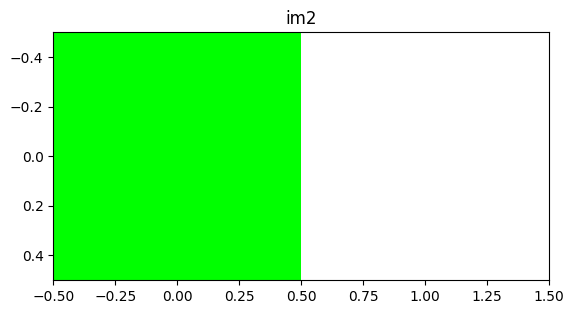

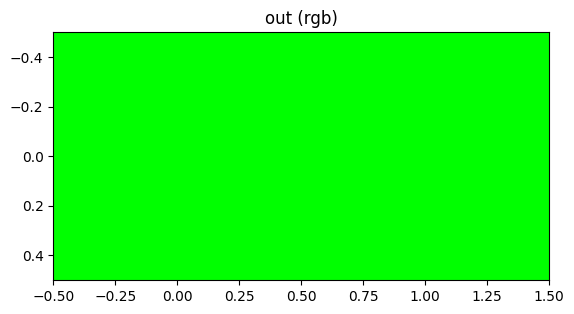

<Figure size 640x480 with 0 Axes>

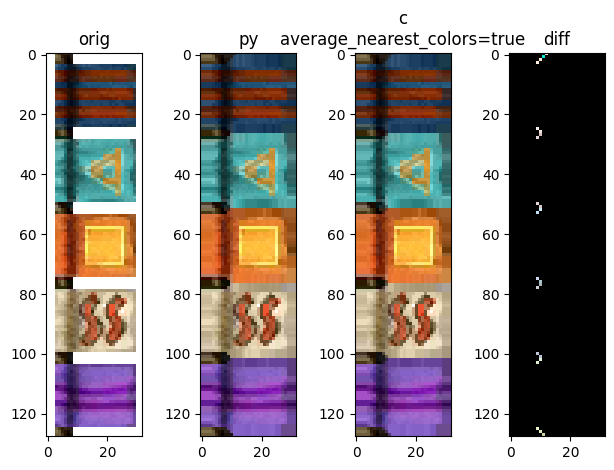

In [49]:
import ctypes

import matplotlib.pyplot as plt
import numpy as np


pg = ctypes.CDLL("./alpha_bleeder.so")

pg.alpha_bleeder.argtypes = [
    ctypes.POINTER(ctypes.c_uint8),
    ctypes.c_int,
    ctypes.c_int,
    ctypes.POINTER(ctypes.c_uint8),
    ctypes.c_int,
    ctypes.c_bool,
]
pg.alpha_bleeder.restype = None


im2 = np.array(
    [
        [
            [0, 255, 0, 255],
            [0, 0, 0, 0],
        ]
    ],
    dtype=np.uint8,
)
print(im2.shape)
print(im2.dtype)
plt.figure()
plt.imshow(im2, interpolation="nearest")
plt.title("im2")

im2_h, im2_w, _ = im2.shape

out = np.empty_like(im2)
pg.alpha_bleeder(
    (ctypes.c_uint8 * (im2_w * im2_h * 4)).from_buffer(im2.data),
    im2_w,
    im2_h,
    (ctypes.c_uint8 * (im2_w * im2_h * 4)).from_buffer(out.data),
    0,
    True,
)

plt.figure()
plt.imshow(out[:, :, :3], interpolation="nearest")
plt.title("out (rgb)")


def c_alpha_bleeder(im, iteration_limit=0, average_nearest_colors=True):
    im_h, im_w, _ = im.shape
    out = np.empty_like(im)
    im_array_type = ctypes.c_uint8 * (im_w * im_h * 4)
    pg.alpha_bleeder(
        im_array_type.from_buffer(im.data),
        im_w,
        im_h,
        im_array_type.from_buffer(out.data),
        iteration_limit,
        average_nearest_colors,
    )
    return out


plt.figure()
fig, axs = plt.subplots(1, 4)
axs[0].imshow(im, interpolation="nearest")
axs[0].set_title("orig")
axs[1].imshow(alpha_bleeder_extend_neighbours(im)[:, :, :3], interpolation="nearest")
axs[1].set_title("py")
axs[2].imshow(c_alpha_bleeder(im)[:, :, :3], interpolation="nearest")
axs[2].set_title("c\naverage_nearest_colors=true")
axs[3].imshow(
    (c_alpha_bleeder(im) - alpha_bleeder_extend_neighbours(im))[:, :, :3],
    interpolation="nearest",
)
axs[3].set_title("diff")
fig.tight_layout()

In [50]:
if 0:
    t1 = []
    for _ in range(2):
        t = time.time()
        alpha_bleeder_naive(im)
        t1.append(time.time() - t)
    print(min(t1), t1)

t2 = []
for _ in range(50):
    t = time.time()
    alpha_bleeder_naive_opt_search(im)
    t2.append(time.time() - t)
print(min(t2), t2)

t3 = []
for _ in range(50):
    t = time.time()
    alpha_bleeder_extend_neighbours(im)
    t3.append(time.time() - t)
print(min(t3), t3)

t4 = []
for _ in range(50):
    t = time.time()
    c_alpha_bleeder(im)
    t4.append(time.time() - t)
print(min(t4), t4)

0.03129982948303223 [0.03921961784362793, 0.03129982948303223, 0.031972646713256836, 0.03357505798339844, 0.033675193786621094, 0.03431868553161621, 0.03468179702758789, 0.03582906723022461, 0.03432774543762207, 0.03293037414550781, 0.03287148475646973, 0.0338597297668457, 0.03227519989013672, 0.038045644760131836, 0.035150766372680664, 0.05125141143798828, 0.04279279708862305, 0.03982686996459961, 0.035614728927612305, 0.035196781158447266, 0.035633087158203125, 0.04156756401062012, 0.034945011138916016, 0.03353309631347656, 0.032575130462646484, 0.03325033187866211, 0.035761356353759766, 0.03676438331604004, 0.03641223907470703, 0.05110311508178711, 0.0622553825378418, 0.043462514877319336, 0.04192304611206055, 0.03696751594543457, 0.03659772872924805, 0.03689932823181152, 0.036443233489990234, 0.03485417366027832, 0.0357823371887207, 0.03739595413208008, 0.03557252883911133, 0.0366668701171875, 0.03463101387023926, 0.0366976261138916, 0.03714442253112793, 0.03638577461242676, 0.0354